In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import json
import os
from sklearn.preprocessing import label_binarize
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score, accuracy_score, auc, f1_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

In [2]:
df_a_o_a_f = pd.read_csv("../data/data_cleaned_with_all_outliers_and_all_features.csv", index_col=0)
df_a_o_a_f.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,0
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,2
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,0
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,2
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,2


In [3]:
target_mapping = {0: 'Dropout', 1: 'Enrolled', 2: 'Graduate'}
print("Target Mapping:", target_mapping)
print("\nTarget Distribution:")
print(df_a_o_a_f['Target'].value_counts(normalize=True).sort_index().round(4))

Target Mapping: {0: 'Dropout', 1: 'Enrolled', 2: 'Graduate'}

Target Distribution:
Target
0    0.3212
1    0.1795
2    0.4993
Name: proportion, dtype: float64


In [4]:
X_eval = df_a_o_a_f.drop(columns=['Target'])
y_eval = df_a_o_a_f['Target']

X_train_eval, X_test_eval, y_train_eval, y_test_eval = train_test_split(
    X_eval, y_eval, test_size=0.2, random_state=42, stratify=y_eval
)

print("Evaluation Dataset Shape:", X_eval.shape)
print("Train Shape:", X_train_eval.shape)
print("Test Shape :", X_test_eval.shape)

Evaluation Dataset Shape: (4424, 34)
Train Shape: (3539, 34)
Test Shape : (885, 34)


In [5]:
RF_DIR  = "../models/random_forest_classifier_model"
DT_DIR  = "../models/decision_tree_classifier_model"
XGB_DIR = "../models/xgboost_classifier_model"

best_rf_model  = joblib.load(os.path.join(RF_DIR,  [f for f in os.listdir(RF_DIR)  if f.endswith('.pkl')][0]))
best_dt_model  = joblib.load(os.path.join(DT_DIR,  [f for f in os.listdir(DT_DIR)  if f.endswith('.pkl')][0]))
best_xgb_model = joblib.load(os.path.join(XGB_DIR, [f for f in os.listdir(XGB_DIR) if f.endswith('.pkl')][0]))

# Re-train all models on the same training split for fair comparison
rf_eval_model = RandomForestClassifier(**best_rf_model.get_params())
dt_eval_model = DecisionTreeClassifier(**best_dt_model.get_params())
xgb_eval_model = XGBClassifier(**best_xgb_model.get_params())

rf_eval_model.fit(X_train_eval, y_train_eval)
dt_eval_model.fit(X_train_eval, y_train_eval)
xgb_eval_model.fit(X_train_eval, y_train_eval)

print("✅ RF MODEL LOADED & RE-TRAINED :", type(rf_eval_model).__name__)
print("✅ DT MODEL LOADED & RE-TRAINED :", type(dt_eval_model).__name__)
print("✅ XGB MODEL LOADED & RE-TRAINED:", type(xgb_eval_model).__name__)

✅ RF MODEL LOADED & RE-TRAINED : RandomForestClassifier
✅ DT MODEL LOADED & RE-TRAINED : DecisionTreeClassifier
✅ XGB MODEL LOADED & RE-TRAINED: XGBClassifier


In [6]:
rf_pred  = rf_eval_model.predict(X_test_eval)
dt_pred  = dt_eval_model.predict(X_test_eval)
xgb_pred = xgb_eval_model.predict(X_test_eval)

rf_proba  = rf_eval_model.predict_proba(X_test_eval)
dt_proba  = dt_eval_model.predict_proba(X_test_eval)
xgb_proba = xgb_eval_model.predict_proba(X_test_eval)

In [7]:
models_eval = [
    ("Random Forest", rf_eval_model, y_test_eval, rf_pred, rf_proba),
    ("Decision Tree", dt_eval_model, y_test_eval, dt_pred, dt_proba),
    ("XGBoost", xgb_eval_model, y_test_eval, xgb_pred, xgb_proba),
]

results = []
for name, model, y_test, y_pred, y_proba in models_eval:
    cv_scores = cross_val_score(
        model, X_train_eval, y_train_eval, cv=5, scoring='accuracy', n_jobs=-1
    )
    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'F1 (Macro)': round(f1_score(y_test, y_pred, average='macro'), 4),
        'F1 (Weighted)': round(f1_score(y_test, y_pred, average='weighted'), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_proba, multi_class='ovr'), 4),
        'CV Mean (5-Fold)': round(cv_scores.mean(), 4),
        'CV Std': round(cv_scores.std(), 4)
    })

df_results = pd.DataFrame(results).set_index('Model')
print("="*70)
print("MODEL COMPARISON — FAIR EVALUATION (SAME SPLIT)")
print("="*70)
print(df_results.to_string())
print("="*70)
print()
print("="*70)
print("🏆 BEST PER METRIC:")
print("="*70)
for col in df_results.columns:
    print(f"   {col:20s}: {df_results[col].idxmax()} ({df_results[col].max():.4f})")
print("="*70)

MODEL COMPARISON — FAIR EVALUATION (SAME SPLIT)
               Accuracy  F1 (Macro)  F1 (Weighted)  ROC-AUC  CV Mean (5-Fold)  CV Std
Model                                                                                
Random Forest    0.7763      0.7063         0.7654   0.8876            0.7751  0.0088
Decision Tree    0.7277      0.6514         0.7182   0.8191            0.7222  0.0146
XGBoost          0.7751      0.7095         0.7675   0.8905            0.7799  0.0102

🏆 BEST PER METRIC:
   Accuracy            : Random Forest (0.7763)
   F1 (Macro)          : XGBoost (0.7095)
   F1 (Weighted)       : XGBoost (0.7675)
   ROC-AUC             : XGBoost (0.8905)
   CV Mean (5-Fold)    : XGBoost (0.7799)
   CV Std              : Decision Tree (0.0146)


In [8]:
for name, _, y_test, y_pred, _ in models_eval:
    print('='*60)
    print(f"CLASSIFICATION REPORT — {name}")
    print('='*60)
    print(classification_report(y_test, y_pred, target_names=['Dropout', 'Enrolled', 'Graduate']))

CLASSIFICATION REPORT — Random Forest
              precision    recall  f1-score   support

     Dropout       0.84      0.74      0.79       284
    Enrolled       0.57      0.41      0.48       159
    Graduate       0.79      0.93      0.86       442

    accuracy                           0.78       885
   macro avg       0.73      0.69      0.71       885
weighted avg       0.77      0.78      0.77       885

CLASSIFICATION REPORT — Decision Tree
              precision    recall  f1-score   support

     Dropout       0.76      0.71      0.73       284
    Enrolled       0.45      0.35      0.40       159
    Graduate       0.78      0.88      0.82       442

    accuracy                           0.73       885
   macro avg       0.66      0.65      0.65       885
weighted avg       0.71      0.73      0.72       885

CLASSIFICATION REPORT — XGBoost
              precision    recall  f1-score   support

     Dropout       0.81      0.75      0.78       284
    Enrolled       0.

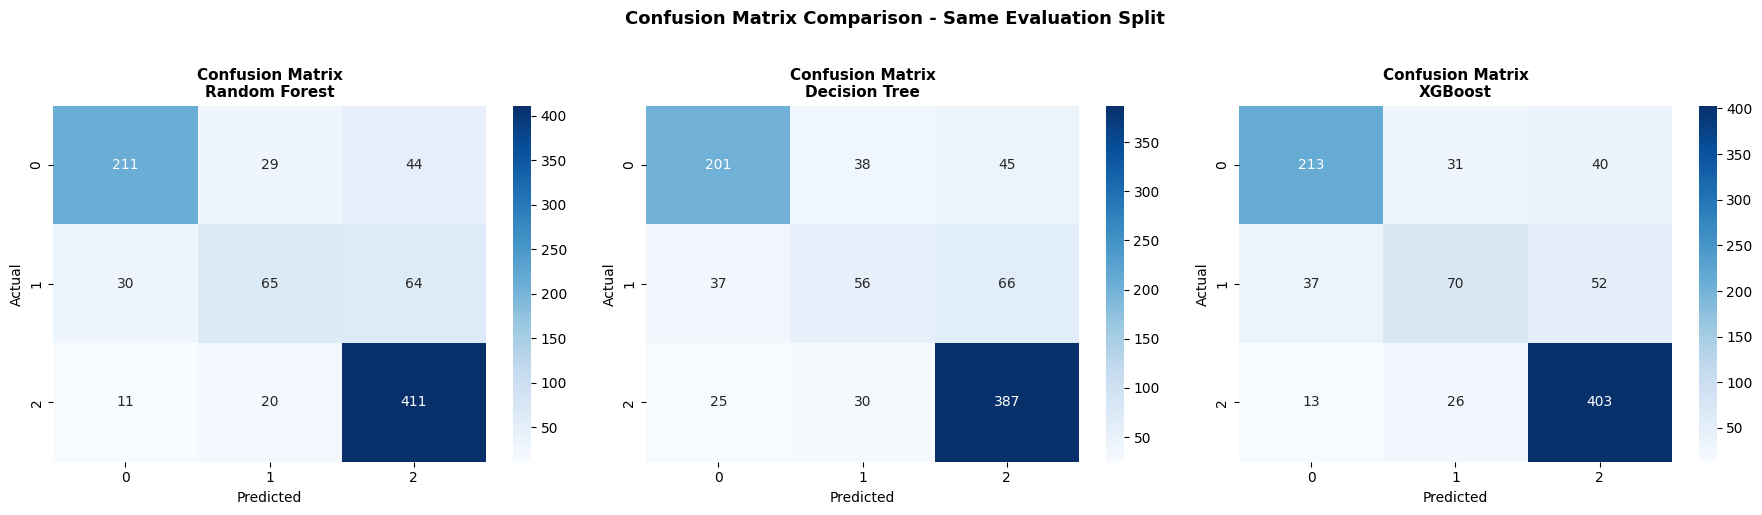

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (name, _, y_test, y_pred, _) in enumerate(models_eval):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(f"Confusion Matrix\n{name}", fontsize=11, fontweight='bold')
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")

plt.suptitle("Confusion Matrix Comparison - Same Evaluation Split", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

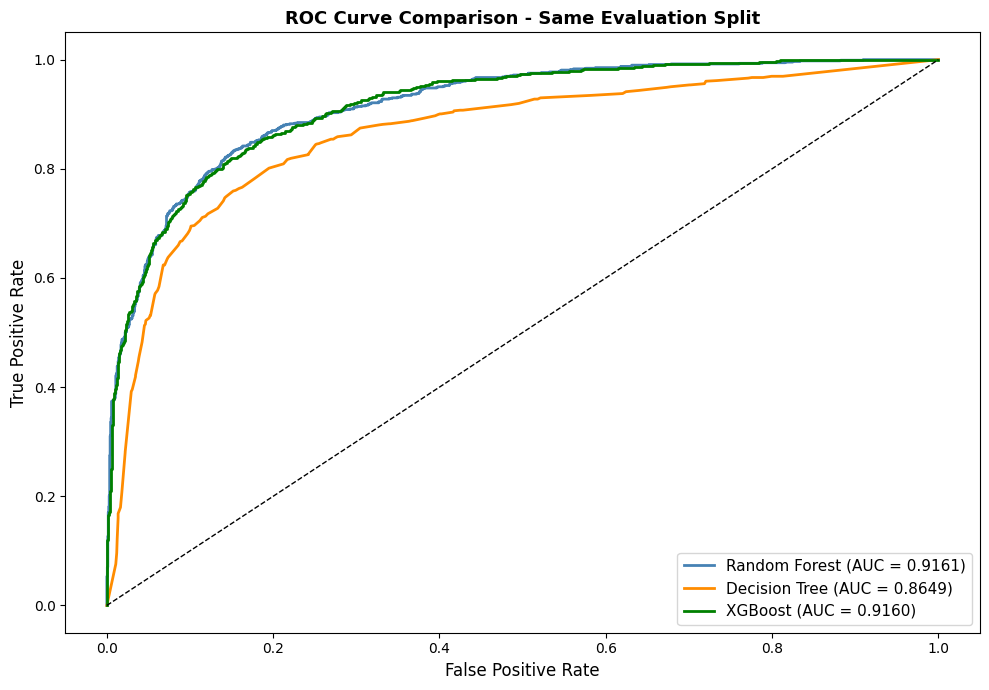

In [10]:
colors = ['steelblue', 'darkorange', 'green']

plt.figure(figsize=(10, 7))
for (name, _, y_test, _, y_proba), color in zip(models_eval, colors):
    y_bin = label_binarize(y_test, classes=np.unique(y_test_eval))
    fpr, tpr, _ = roc_curve(y_bin.ravel(), y_proba.ravel())
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, color=color, label=f"{name} (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve Comparison - Same Evaluation Split", fontsize=13, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.tight_layout()
plt.show()

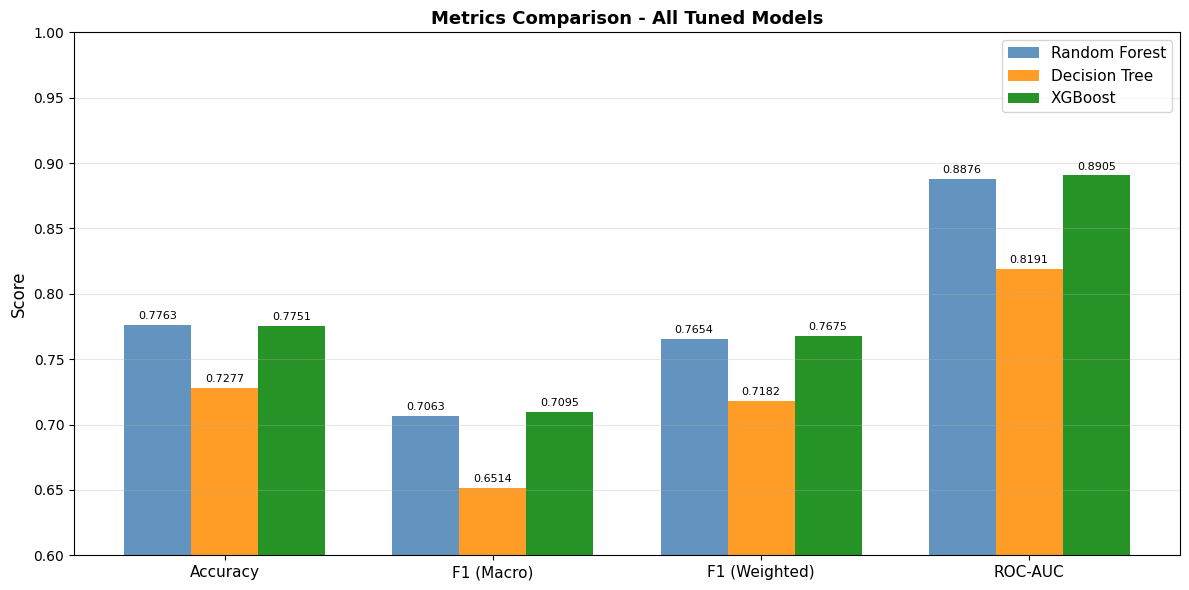

In [11]:
df_plot = df_results.reset_index()
metrics = ['Accuracy', 'F1 (Macro)', 'F1 (Weighted)', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.25
colors = ['steelblue', 'darkorange', 'green']

fig, ax = plt.subplots(figsize=(12, 6))
for i, (_, row) in enumerate(df_plot.iterrows()):
    bars = ax.bar(x + i * width, [row[m] for m in metrics],
                  width, label=row['Model'], color=colors[i], alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.003,
                f"{bar.get_height():.4f}",
                ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel("Score", fontsize=12)
ax.set_ylim(0.6, 1.0)
ax.set_title("Metrics Comparison - All Tuned Models", fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
print("="*70)
print("FINAL MODEL COMPARISON SUMMARY (SAME EVALUATION SPLIT)")
print("="*70)
print(df_results.to_string())

best_model_name = df_results['ROC-AUC'].idxmax()

print("="*70)
print(f"🏆 BEST OVERALL MODEL (by ROC-AUC): {best_model_name}")
print("="*70)
print(f"ROC-AUC         : {df_results.loc[best_model_name, 'ROC-AUC']}")
print(f"Accuracy        : {df_results.loc[best_model_name, 'Accuracy']}")
print(f"F1 (Weighted)   : {df_results.loc[best_model_name, 'F1 (Weighted)']}")
print(f"CV Mean (5-Fold): {df_results.loc[best_model_name, 'CV Mean (5-Fold)']}")
print(f"CV Std          : {df_results.loc[best_model_name, 'CV Std']}")
print("="*70)

FINAL MODEL COMPARISON SUMMARY (SAME EVALUATION SPLIT)
               Accuracy  F1 (Macro)  F1 (Weighted)  ROC-AUC  CV Mean (5-Fold)  CV Std
Model                                                                                
Random Forest    0.7763      0.7063         0.7654   0.8876            0.7751  0.0088
Decision Tree    0.7277      0.6514         0.7182   0.8191            0.7222  0.0146
XGBoost          0.7751      0.7095         0.7675   0.8905            0.7799  0.0102
🏆 BEST OVERALL MODEL (by ROC-AUC): XGBoost
ROC-AUC         : 0.8905
Accuracy        : 0.7751
F1 (Weighted)   : 0.7675
CV Mean (5-Fold): 0.7799
CV Std          : 0.0102


In [13]:
best_pred_lookup = {
    'Random Forest': rf_pred,
    'Decision Tree': dt_pred,
    'XGBoost': xgb_pred
}

best_pred = best_pred_lookup[best_model_name]

best_report = classification_report(
    y_test_eval,
    best_pred,
    target_names=['Dropout', 'Enrolled', 'Graduate'],
    output_dict=True
)

print("="*70)
print("VALIDATION CHECK - CLASS LEVEL")
print("="*70)
print("Recall Dropout :", round(best_report['Dropout']['recall'], 4))
print("Recall Enrolled:", round(best_report['Enrolled']['recall'], 4))
print("Recall Graduate:", round(best_report['Graduate']['recall'], 4))
print("="*70)

# Simple business simulation for dropout intervention
dropout_class = 0
tp_dropout = int(((y_test_eval == dropout_class) & (best_pred == dropout_class)).sum())
fp_dropout = int(((y_test_eval != dropout_class) & (best_pred == dropout_class)).sum())
fn_dropout = int(((y_test_eval == dropout_class) & (best_pred != dropout_class)).sum())

intervention_cost_per_student = 150
dropout_loss_per_student = 1200

prevented_dropout_value = tp_dropout * dropout_loss_per_student
intervention_cost_total = (tp_dropout + fp_dropout) * intervention_cost_per_student
missed_dropout_loss = fn_dropout * dropout_loss_per_student
net_impact = prevented_dropout_value - intervention_cost_total - missed_dropout_loss

print("BUSINESS VALUE SIMULATION")
print(f"TP Dropout Alerts : {tp_dropout}")
print(f"FP Dropout Alerts : {fp_dropout}")
print(f"FN Missed Dropout : {fn_dropout}")
print(f"Estimated Prevented Loss : {prevented_dropout_value}")
print(f"Intervention Cost Total  : {intervention_cost_total}")
print(f"Missed Dropout Loss      : {missed_dropout_loss}")
print(f"Estimated Net Impact     : {net_impact}")

business_eval_df = X_test_eval.copy()
business_eval_df['pred_target'] = best_pred
business_eval_df['pred_dropout'] = (business_eval_df['pred_target'] == dropout_class).astype(int)

if 'Age at enrollment' in business_eval_df.columns:
    age_max = int(np.ceil(business_eval_df['Age at enrollment'].max())) + 1
    business_eval_df['age_group'] = pd.cut(
        business_eval_df['Age at enrollment'],
        bins=[0, 20, 25, 30, age_max],
        labels=['<=20', '21-25', '26-30', '31+'],
        include_lowest=True
    )

    age_group_dropout_rate = business_eval_df.groupby('age_group', observed=False)['pred_dropout'].mean().round(4)
    print("\nFAIRNESS PROXY - Predicted Dropout Rate by Age Group")
    print(age_group_dropout_rate.to_string())

if 'Tuition fees up to date' in business_eval_df.columns:
    tuition_group_dropout_rate = business_eval_df.groupby('Tuition fees up to date')['pred_dropout'].mean().round(4)
    tuition_group_dropout_rate.index = tuition_group_dropout_rate.index.map({0: 'Not Up to Date', 1: 'Up to Date'})
    print("\nFAIRNESS PROXY - Predicted Dropout Rate by Tuition Status")
    print(tuition_group_dropout_rate.to_string())

VALIDATION CHECK - CLASS LEVEL
Recall Dropout : 0.75
Recall Enrolled: 0.4403
Recall Graduate: 0.9118
BUSINESS VALUE SIMULATION
TP Dropout Alerts : 213
FP Dropout Alerts : 50
FN Missed Dropout : 71
Estimated Prevented Loss : 255600
Intervention Cost Total  : 39450
Missed Dropout Loss      : 85200
Estimated Net Impact     : 130950

FAIRNESS PROXY - Predicted Dropout Rate by Age Group
age_group
<=20     0.1837
21-25    0.3056
26-30    0.5227
31+      0.5669

FAIRNESS PROXY - Predicted Dropout Rate by Tuition Status
Tuition fees up to date
Not Up to Date    0.9633
Up to Date        0.2036


## Model Comparison Summary (Updated from Latest Rerun)

### Fair Evaluation Setup
- Ketiga model dievaluasi pada dataset dan split yang sama: `data_cleaned_with_all_outliers_and_all_features.csv`
- Train-test split: 80:20, `random_state=42`, `stratify=Target`

### Metrics Snapshot
| Model | Accuracy | F1 (Macro) | F1 (Weighted) | ROC-AUC | CV Mean (5-Fold) | CV Std |
|---|---:|---:|---:|---:|---:|---:|
| Random Forest | 0.7763 | 0.7063 | 0.7654 | 0.8876 | 0.7751 | 0.0088 |
| Decision Tree | 0.7277 | 0.6514 | 0.7182 | 0.8191 | 0.7222 | 0.0146 |
| XGBoost | 0.7751 | 0.7095 | 0.7675 | 0.8905 | 0.7799 | 0.0102 |

### Best Overall Model
- **XGBoost** (by ROC-AUC): 0.8905
- Accuracy: 0.7751
- F1 (Weighted): 0.7675
- CV Mean / Std: 0.7799 / 0.0102

### Validation and Business Snapshot
- Class recall (best model): Dropout 0.7500, Enrolled 0.4403, Graduate 0.9118
- Dropout intervention simulation: TP 213, FP 50, FN 71
- Estimated net impact: **+130,950**

### Fairness Proxy Snapshot
- Predicted dropout rate by age group: <=20 (0.1837), 21-25 (0.3056), 26-30 (0.5227), 31+ (0.5669)
- Predicted dropout rate by tuition status: Not Up to Date (0.9633), Up to Date (0.2036)

### Recommendation
- Gunakan **XGBoost** sebagai kandidat deployment utama berdasarkan ROC-AUC tertinggi dan CV mean tertinggi pada setup evaluasi yang adil.